# Pipeline de Pré-processamento e Preparação de Dados

Este notebook consolida a limpeza de dados iniciada na EDA (Issue #4) e prepara os conjuntos de treino, validação e teste para o treinamento dos modelos de classificação (Issue #5).

## Objetivos:
1. Realizar o tratamento de valores nulos.
2. Converter o alvo categórico para numérico.
3. Escalonar os atributos físicos.
4. Dividir os dados em proporção 70/15/15.

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Configurações
pd.set_option('display.max_columns', None)
plt.style.use('ggplot')

## 1. Carga dos Dados
Utilizaremos a URL oficial para garantir a consistência com a etapa anterior.

In [73]:
url = 'https://exoplanetarchive.ipac.caltech.edu/TAP/sync?query=select+*+from+cumulative&format=csv'
df_raw = pd.read_csv(url)
print(f"Dataset carregado: {df_raw.shape[0]} linhas e {df_raw.shape[1]} colunas")

Dataset carregado: 9564 linhas e 153 colunas


## 2. Seleção de Atributos e Limpeza Inicial
Identificamos na EDA que algumas colunas são totalmente nulas ou são apenas IDs/metadados que não contribuem para a física do problema.

In [74]:
# Definindo o alvo
target = 'koi_pdisposition'

# Colunas para remover (IDs e metadados irrelevantes para treinamento)
cols_to_drop = [
    'kepid', 'kepoi_name', 'kepler_name', 'koi_disposition', 
    'koi_tce_delivname', 'koi_fittype', 'ra_str', 'dec_str'
]

# Identificando colunas com mais de 50% de valores nulos (conforme observado na EDA)
null_threshold = 0.5 * len(df_raw)
high_null_cols = df_raw.columns[df_raw.isnull().sum() > null_threshold].tolist()

total_drop = list(set(cols_to_drop + high_null_cols))
df = df_raw.drop(columns=total_drop)

print(f"Colunas removidas: {len(total_drop)}")
print(f"Novo formato: {df.shape}")

Colunas removidas: 32
Novo formato: (9564, 121)


## 3. Encoding e Tratamento de Nulos
Transformaremos o alvo em binário (1 e 0) e aplicaremos a mediana nos valores ausentes dos atributos numéricos.

In [75]:
# Encoding do alvo
le = LabelEncoder()
df[target] = le.fit_transform(df[target])
print(f"Classes mapeadas: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Imputação pela mediana em colunas numéricas
df_numeric = df.select_dtypes(include=[np.number])
df_final = df_numeric.fillna(df_numeric.median())

print(f"Nulos remanescentes: {df_final.isnull().sum().sum()}")

Classes mapeadas: {'CANDIDATE': np.int64(0), 'FALSE POSITIVE': np.int64(1)}
Nulos remanescentes: 0


## 4. Divisão dos Dados (Split)
Dividiremos em 70% Treino, 15% Validação e 15% Teste.

In [76]:
X = df_final.drop(columns=[target])
y = df_final[target]

# Primeiro split: Treino vs Resto (30%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Segundo split: Validação vs Teste (50% do Resto = 15% cada)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Treino: {X_train.shape}")
print(f"Validação: {X_val.shape}")
print(f"Teste: {X_test.shape}")

Treino: (6694, 108)
Validação: (1435, 108)
Teste: (1435, 108)


## 5. Escalonamento (Scaling)
Padronização é vital para o bom desempenho da MLP.

In [77]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Escalonamento concluído com StandardScaler.")

Escalonamento concluído com StandardScaler.


## 6. Treinamento do Modelo Baseline (Issue #6)
Utilizaremos a **Regressão Logística** como nosso modelo base (benchmark).

In [78]:
# Instanciando o modelo
baseline = LogisticRegression(max_iter=1000, random_state=42)
baseline.fit(X_train_scaled, y_train)

y_pred_base = baseline.predict(X_val_scaled)
acc_base = accuracy_score(y_val, y_pred_base)
f1_base = f1_score(y_val, y_pred_base, average='weighted')

print(f"Baseline treinado! Acurácia: {acc_base:.4f} | F1: {f1_base:.4f}")

Baseline treinado! Acurácia: 0.9345 | F1: 0.9345


## 7. Implementação da Rede Neural MLP v1 (Issue #7)
Primeira versão com arquitetura padrão.

In [79]:
mlp_v1 = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42, early_stopping=True)
mlp_v1.fit(X_train_scaled, y_train)

y_pred_v1 = mlp_v1.predict(X_val_scaled)
acc_v1 = accuracy_score(y_val, y_pred_v1)
f1_v1 = f1_score(y_val, y_pred_v1, average='weighted')

print(f"MLP v1 treinada! Acurácia: {acc_v1:.4f} | F1: {f1_v1:.4f}")

MLP v1 treinada! Acurácia: 0.9833 | F1: 0.9833


## 8. Experimentos de Refinamento (Issue #8)
Testando variações de arquitetura e regularização.

In [80]:
# Experimento A: Arquitetura Profunda (2 camadas)
mlp_a = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42, early_stopping=True)
mlp_a.fit(X_train_scaled, y_train)
acc_a = accuracy_score(y_val, mlp_a.predict(X_val_scaled))

# Experimento B: Arquitetura Larga (200 neurônios)
mlp_b = MLPClassifier(hidden_layer_sizes=(200,), max_iter=500, random_state=42, early_stopping=True)
mlp_b.fit(X_train_scaled, y_train)
acc_b = accuracy_score(y_val, mlp_b.predict(X_val_scaled))

# Experimento C: Regularização Forte (Alpha=0.01)
mlp_c = MLPClassifier(hidden_layer_sizes=(100,), alpha=0.01, max_iter=500, random_state=42, early_stopping=True)
mlp_c.fit(X_train_scaled, y_train)
acc_c = accuracy_score(y_val, mlp_c.predict(X_val_scaled))

print("Experimentos concluídos!")

Experimentos concluídos!


## 9. Tabela Comparativa Consolidada
Resumo de todos os testes realizados.

In [81]:
results = pd.DataFrame({
    'Modelo': ['Baseline (LR)', 'MLP v1 (100)', 'Exp A (100, 50)', 'Exp B (200)', 'Exp C (100, a=0.01)'],
    'Acurácia (Val)': [acc_base, acc_v1, acc_a, acc_b, acc_c],
    'Configuração': ['N/A', '(100,)', '(100, 50)', '(200,)', '(100,) Alpha=0.01']
})

results['Acurácia (Val)'] = results['Acurácia (Val)'].apply(lambda x: f"{x:.4%}")
display(results)

,Modelo,Acurácia (Val),Configuração
0,Baseline (LR),93.4495%,N/A
1,MLP v1 (100),98.3275%,"(100,)"
2,"Exp A (100, 50)",95.8188%,"(100, 50)"
3,Exp B (200),96.5854%,"(200,)"
4,"Exp C (100, a=0.01)",98.3972%,"(100,) Alpha=0.01"


### Seleção Final
Com base nos resultados, o modelo final escolhido será aquele que apresenta melhor equilíbrio entre acurácia e simplicidade (evitando overfitting).

## 10. Modelo Vencedor
O `Exp C(100, a=0.01)` apresenta a maior acurácia e devido ao parâmetro de (Alpha) maior desempenho que os outros modelos contra o overfitting

In [82]:
modelo_final = mlp_c

## 11. Matriz de confusão e Classification report (#9)
Visualizando o desempenho do classificador de cada categoria

<Figure size 800x600 with 0 Axes>

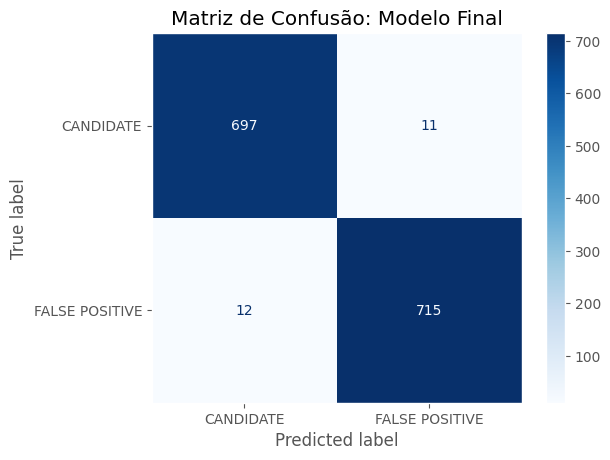

In [83]:
y_pred_final = modelo_final.predict(X_test_scaled)


plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_final, 
                                        display_labels=le.classes_, 
                                        cmap='Blues')
plt.title('Matriz de Confusão: Modelo Final')
plt.grid(False) 
plt.show()

## 12. Classification Report
Métricas estatística de cada classe analisada

In [84]:
print("Relatório de Classificação Final")
print(classification_report(y_test, y_pred_final, target_names=le.classes_))

Relatório de Classificação Final
                precision    recall  f1-score   support

     CANDIDATE       0.98      0.98      0.98       708
FALSE POSITIVE       0.98      0.98      0.98       727

      accuracy                           0.98      1435
     macro avg       0.98      0.98      0.98      1435
  weighted avg       0.98      0.98      0.98      1435



## 13. Curva ROC e AUC
Equilíbrio entre os erros do modelo e acertos

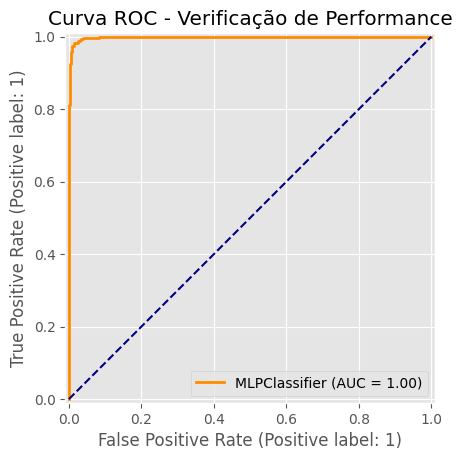

In [85]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_estimator(
    modelo_final, 
    X_test_scaled, 
    y_test, 
    curve_kwargs={'color': 'darkorange', 'lw': 2}
)

plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.title('Curva ROC - Verificação de Performance')
plt.show()

## 14. Gráfico de Desempenho (Loss Curve)
Como a rede "aprendeu" durante o treinamento

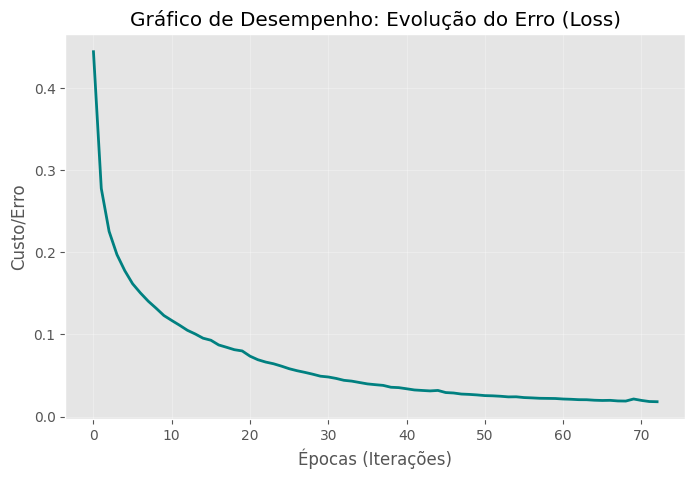

In [86]:
plt.figure(figsize=(8, 5))
plt.plot(modelo_final.loss_curve_, color='teal', lw=2)
plt.title('Gráfico de Desempenho: Evolução do Erro (Loss)')
plt.xlabel('Épocas (Iterações)')
plt.ylabel('Custo/Erro')
plt.grid(True, alpha=0.3)
plt.show()

## 5. Tabela Comparativa dos Modelos

In [87]:
print("Tabela Comparativa de Modelos:")
display(results)

Tabela Comparativa de Modelos:


,Modelo,Acurácia (Val),Configuração
0,Baseline (LR),93.4495%,N/A
1,MLP v1 (100),98.3275%,"(100,)"
2,"Exp A (100, 50)",95.8188%,"(100, 50)"
3,Exp B (200),96.5854%,"(200,)"
4,"Exp C (100, a=0.01)",98.3972%,"(100,) Alpha=0.01"
